# Assignment 3: Neural N-Gram Language Model

Make the run deterministic. Call torch.manual_seed and report the seed.

This assignment runs on a CPU. A GPU is not needed. Write the device once and use it everywhere:

device = "cuda" if torch.cuda.is_available() else "cpu

In [1]:
import time
import math
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from bpe import BPETokenizer, normalize

SEED = 1337
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
print("Seed:", SEED)

Device: cpu
Seed: 1337


Use the same corpus and the same three splits as in Assignment 2. Encode the splits with your BPE tokenizer, with bos and eos, exactly as before

In [2]:
import pathlib

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
local_path = pathlib.Path("data/shakespeare.txt")

if local_path.exists():
    text = local_path.read_text(encoding="utf-8")
else:
    response = requests.get(url)
    response.encoding = "utf-8"
    text = response.text

lines = text.splitlines()

# same 80/10/10 split as in Assignment 2
train_end = int(len(lines) * 0.8)
val_end = int(len(lines) * 0.9)

train_lines = lines[:train_end]
val_lines = lines[train_end:val_end]
test_lines = lines[val_end:]

train_text = "\n".join(train_lines)

# same BPE setup as in Assignment 2
strategy = "clean"

tok = BPETokenizer(
    num_merges=1000,
    end_of_word="</w>",
    strategy=strategy
)

train_text_normalized = normalize(train_text, strategy)
tok.train(train_text_normalized)

# same bos and eos handling as in Assignment 2
tok.vocab.pop("<bos>", None)
tok.vocab.pop("<eos>", None)

tok.vocab["<bos>"] = len(tok.vocab)
tok.vocab["<eos>"] = len(tok.vocab)

bos_id = tok.vocab["<bos>"]
eos_id = tok.vocab["<eos>"]

n = 3

train_ids = [
    [bos_id] * (n - 1)
    + tok.encode(line, count_unk=False)
    + [eos_id]
    for line in train_lines
]

val_ids = [
    [bos_id] * (n - 1)
    + tok.encode(line, count_unk=False)
    + [eos_id]
    for line in val_lines
]

test_ids = [
    [bos_id] * (n - 1)
    + tok.encode(line, count_unk=False)
    + [eos_id]
    for line in test_lines
]

print("BOS ID:", bos_id)
print("EOS ID:", eos_id)

print("Training sequences:", len(train_ids))
print("Validation sequences:", len(val_ids))
print("Test sequences:", len(test_ids))

BOS ID: 1039
EOS ID: 1040
Training sequences: 32000
Validation sequences: 4000
Test sequences: 4000


Task 1.1

Turn each split into one long list of token ids. Keep the bos and eos tokens from Assignment 2.

In [3]:
train_ids = [
    token
    for sequence in train_ids
    for token in sequence
]

val_ids = [
    token
    for sequence in val_ids
    for token in sequence
]

test_ids = [
    token
    for sequence in test_ids
    for token in sequence
]

print("Train tokens:", len(train_ids))
print("Validation tokens:", len(val_ids))
print("Test tokens:", len(test_ids))

Train tokens: 387081
Validation tokens: 48924
Test tokens: 46795


Task 1.2

Write get_batch(split, batch_size). It returns x of shape (batch_size, n-1) and y of shape (batch_size,), both torch.long and both on the device

In [4]:
def get_batch(split, batch_size):

    # choosing random starting positions
    indices = torch.randint(
        0,
        len(split) - (n - 1),
        (batch_size,)
    )

    # n-1 tokens are the input
    x = torch.tensor(
        [split[i:i + n - 1] for i in indices],
        dtype=torch.long,
        device=device
    )

    # token after context is the target
    y = torch.tensor(
        [split[i + n - 1] for i in indices],
        dtype=torch.long,
        device=device
    )

    return x, y

Task 1.3

Print one batch with small numbers, and decode one row by hand, to show that the target is the token that follows the context.

In [5]:
# getting small batch with 4 examples
x, y = get_batch(train_ids, batch_size=4)

# printing input contexts and target tokens
print("x:", x)
print("y:", y)

# reversing vocab dictionary so we can get token from token id
id_to_token = {i: token for token, i in tok.vocab.items()}

# getting tokens of first context and translating ids back to tokens
print("Context:", [id_to_token[i] for i in x[0].tolist()])

# getting target of first example and translating id back to token
print("Target:", id_to_token[y[0].item()])

x: tensor([[ 158,   25],
        [  31,  724],
        [  50, 1040],
        [1039,  160]])
y: tensor([ 291,   42, 1039,   14])
Context: ['fa', 'm']
Target: ous</w>


Task 2

Write a class NeuralNGramLM. It takes n, the vocabulary size V , the embedding size and the hidden
size.

1. nn.Embedding(V, n_embd) maps each of the n − 1 context ids to a vector.

2. Flatten the n − 1 vectors into one vector of length (n − 1)× n_embd.

3. nn.Linear to the hidden size, then nn.ReLU.

4. nn.Linear from the hidden size to V . These are the logits.

5. forward takes idx and targets, and returns the logits and the loss. Compute the loss with
F.cross_entropy. Return None for the loss when there are no targets.

The two methods that keep the old code working. Add log_prob(token, context) and
next_token_log_probs(context), with the same signatures as in Assignment 2. Then your perplexity and generate functions run on this model without a change. Put the model in
model.eval() and wrap these methods in torch.no_grad().
A loop over single tokens is slow. You may add a batched perplexity function for speed. If you
do, show that it gives the same value as the Assignment 2 function to three decimals.


In [6]:
%%writefile neural_ngram.py

import torch
import torch.nn as nn
import torch.nn.functional as F


class NeuralNGramLM(nn.Module):

    def __init__(self, n, vocab_size, n_embd=64, n_hidden=256):
        super().__init__()

        self.n = n
        self.ctx_len = n - 1
        self.vocab_size = vocab_size

        # converting every token id into an embedding vector
        self.embedding = nn.Embedding(vocab_size, n_embd)

        # taking all context embeddings as one vector
        self.hidden = nn.Linear(self.ctx_len * n_embd, n_hidden)

        self.relu = nn.ReLU()

        # giving one output score for every token in vocabulary
        self.output = nn.Linear(n_hidden, vocab_size)


    def forward(self, idx, targets=None):

        # convert token ids into embeddings
        embeddings = self.embedding(idx)

        # put embeddings of the context into one vector
        flat = embeddings.view(embeddings.shape[0], -1)

        # hidden layer and ReLU
        hidden = self.relu(self.hidden(flat))

        # scores for every possible next token
        logits = self.output(hidden)

        # calculate loss only if targets are given
        loss = None

        if targets is not None:
            loss = F.cross_entropy(logits, targets)

        return logits, loss


    @torch.no_grad()
    def next_token_log_probs(self, context):

        self.eval()

        # only use the previous n-1 tokens
        context = context[-self.ctx_len:]

        # convert context into tensor
        x = torch.tensor(
            [context],
            dtype=torch.long,
            device=next(self.parameters()).device
        )

        # get output scores
        logits, _ = self.forward(x)

        # convert scores into probabilities and then log probabilities
        probabilities = F.softmax(logits[0], dim=-1)
        log_probs = torch.log(probabilities)

        return log_probs.cpu().numpy()


    @torch.no_grad()
    def log_prob(self, token, context):

        # get probabilities for all possible next tokens
        log_probs = self.next_token_log_probs(context)

        # return probability of the wanted token
        return float(log_probs[token])

Overwriting neural_ngram.py


Sanity check. Before training, the model is close to uniform, so the loss should be near ln V. Print it. A much lower value at step zero means the targets are leaking into the input.

In [7]:
from neural_ngram import NeuralNGramLM

In [8]:
# getting vocabulary size
V = len(tok.vocab)

# creating neural n-gram
model = NeuralNGramLM(
    n=3,
    vocab_size=V,
    n_embd=64,
    n_hidden=256
).to(device)

# getting batch with 64 training examples
x, y = get_batch(train_ids, batch_size=64)

# passing batch through model and calcualting loss
logits, loss = model(x, y)

# printing actual loss before training
print("Loss :", loss.item())

# printing expected loss
print("ln(V):", math.log(V))

Loss : 6.942485809326172
ln(V): 6.947937068614969


Task 3


Write the training loop. The order is: get a batch, forward, clear the gradients, backward, step.
Use torch.optim.AdamW.

Write estimate_loss() with the @torch.no_grad() decorator. It averages the loss over
several batches for the training split and the validation split.

Call model.eval() before and
model.train() after.

Print both losses every few hundred steps.

Plot the training loss and the validation loss against the step number, on one plot. Say in one
sentence where the validation loss stops falling.
Start from this configuration: n = 3, k = 1000, n_embd=64, n_hidden=256, batch_size=64,
lr=1e-3, max_steps=2000.

Step 0: train loss 6.9710, val loss 6.9734


Step 200: train loss 4.9063, val loss 4.8723


Step 400: train loss 4.7602, val loss 4.7704


Step 600: train loss 4.6212, val loss 4.6666


Step 800: train loss 4.6029, val loss 4.6049


...

Step 1200: train loss 4.2795, val loss 4.3375


Step 1400: train loss 4.0386, val loss 4.2737


Step 1600: train loss 4.0616, val loss 4.1574


Step 1800: train loss 3.8505, val loss 4.1596


Step 1999: train loss 3.8971, val loss 4.1183
Training time: 4.79 seconds


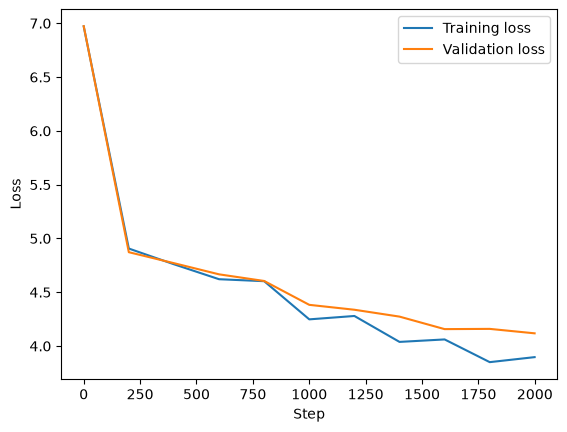

In [9]:
@torch.no_grad()
def estimate_loss(model, train_data, val_data, batch_size=64, eval_batches=50):

    # putting model into evaluation mode
    model.eval()

    train_losses = []
    val_losses = []

    # calculating average training loss
    for _ in range(eval_batches):
        x, y = get_batch(train_data, batch_size)
        logits, loss = model(x, y)
        train_losses.append(loss.item())

    # calculating average validation loss
    for _ in range(eval_batches):
        x, y = get_batch(val_data, batch_size)
        logits, loss = model(x, y)
        val_losses.append(loss.item())

    # putting model back into training mode
    model.train()

    return np.mean(train_losses), np.mean(val_losses)


# val_data can be changed for experiments with different tokenizations (task 4)
def train(model, train_ids, max_steps=2000, lr=0.001,
          batch_size=64, val_data=None):

    # using normal validation data if no other data is given
    if val_data is None:
        val_data = val_ids

    # creating optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # saving results for plot
    steps = []
    train_losses = []
    val_losses = []

    # starting timer
    start_time = time.time()

    # putting model into training mode
    model.train()

    for step in range(max_steps):

        # getting training batch
        x, y = get_batch(train_ids, batch_size)

        # forward pass
        logits, loss = model(x, y)

        # clearing old gradients
        optimizer.zero_grad()

        # calculating gradients
        loss.backward()

        # updating model weights
        optimizer.step()

        # checking losses every 200 steps
        if step % 200 == 0 or step == max_steps - 1:

            train_loss, val_loss = estimate_loss(
                model,
                train_ids,
                val_data,
                batch_size=batch_size
            )

            steps.append(step)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(
                f"Step {step}: "
                f"train loss {train_loss:.4f}, "
                f"val loss {val_loss:.4f}"
            )

    # calculating training time
    training_time = time.time() - start_time

    print(f"Training time: {training_time:.2f} seconds")

    return steps, train_losses, val_losses, training_time



# training model
steps, train_losses, val_losses, training_time = train(
    model,
    train_ids,
    max_steps=2000,
    lr=1e-3,
    batch_size=64
)


# plotting training and validation loss
plt.plot(steps, train_losses, label="Training loss")
plt.plot(steps, val_losses, label="Validation loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()

plt.show()

The validation loss reaches a plateu around step 2000.

Task 4

Experiment 1

 vary k. Train the same model with k ∈ {250, 1000, 4000}. Keep everything else
fixed.

In [10]:
# creating new tokenized data because each k value produces a different BPE vocabulary and tokenization
def prepare_data(k):

    # creating tokenizer with given k
    tok_k = BPETokenizer(
        num_merges=k,
        end_of_word="</w>",
        strategy=strategy
    )

    # training tokenizer on training data
    tok_k.train(normalize(train_text, strategy))

    # adding bos and eos
    tok_k.vocab.pop("<bos>", None)
    tok_k.vocab.pop("<eos>", None)

    tok_k.vocab["<bos>"] = len(tok_k.vocab)
    tok_k.vocab["<eos>"] = len(tok_k.vocab)

    bos_k = tok_k.vocab["<bos>"]
    eos_k = tok_k.vocab["<eos>"]

    # encoding one split
    def encode_split(lines):

        sequences = [
            [bos_k] * (n - 1)
            + tok_k.encode(line, count_unk=False)
            + [eos_k]
            for line in lines
        ]

        # turning split into one long list for neural training
        flat = [
            token
            for sequence in sequences
            for token in sequence
        ]

        return sequences, flat

    train_sequences, train_k = encode_split(train_lines)
    val_sequences, val_k = encode_split(val_lines)
    test_sequences, test_k = encode_split(test_lines)

    return (
        tok_k,
        train_sequences,
        val_sequences,
        test_sequences,
        train_k,
        val_k,
        test_k
    )

In [11]:
k_values = [250, 1000, 4000]

# saving different models
experiment1_models = {}

for k in k_values:

    print("k =", k)

    # resetting seed for reproducibility
    torch.manual_seed(SEED)

    # preparing data for current k
    (
        tok_k,
        train_sequences,
        val_sequences,
        test_sequences,
        train_k,
        val_k,
        test_k
    ) = prepare_data(k)

    # creating model with same configuration
    model_k = NeuralNGramLM(
        n=3,
        vocab_size=len(tok_k.vocab),
        n_embd=64,
        n_hidden=256
    ).to(device)

    # training model
    steps_k, train_losses_k, val_losses_k, training_time_k = train(
        model_k,
        train_k,
        max_steps=2000,
        lr=0.001,
        batch_size=64,
        val_data=val_k
    )

    # saving model and data for evaluation
    experiment1_models[k] = {
        "model": model_k,
        "tokenizer": tok_k,
        "train_sequences": train_sequences,
        "val_sequences": val_sequences,
        "test_sequences": test_sequences,
        "training_time": training_time_k
    }

k = 250


Step 0: train loss 5.6474, val loss 5.6512


Step 200: train loss 4.2179, val loss 4.1577


Step 400: train loss 3.8920, val loss 3.8616


Step 600: train loss 3.6203, val loss 3.7699


...

Step 1200: train loss 4.8055, val loss 5.1064


Step 1400: train loss 4.8089, val loss 5.0999


Step 1600: train loss 4.8046, val loss 5.0717


Step 1800: train loss 4.7105, val loss 4.9865


Step 1999: train loss 4.7112, val loss 4.9572
Training time: 10.06 seconds


Report both perplexities on the validation set and on the test set.

In [12]:
# now using Jeremy's real perplexity from Assignment 2 (evaluation.py),
# not a temporary stand-in anymore
from evaluation import perplexity

# getting number of characters in validation and test data
val_char_count = len("\n".join(val_lines))
test_char_count = len("\n".join(test_lines))

experiment1_results = []

# evaluating all three models
for k in k_values:

    model_k = experiment1_models[k]["model"]
    val_sequences = experiment1_models[k]["val_sequences"]
    test_sequences = experiment1_models[k]["test_sequences"]

    # validation perplexity
    val_pp, val_pp_char = perplexity(
        model_k,
        val_sequences,
        val_char_count
    )

    # test perplexity
    test_pp, test_pp_char = perplexity(
        model_k,
        test_sequences,
        test_char_count
    )

    # saving results
    experiment1_results.append({
        "k": k,
        "Validation PP": val_pp,
        "Validation PP char": val_pp_char,
        "Test PP": test_pp,
        "Test PP char": test_pp_char
    })


# creating result table
experiment1_table = pd.DataFrame(experiment1_results)

display(experiment1_table.round(3))

,k,Validation PP,Validation PP char,Test PP,Test PP char
0,250,43.226,6.496,50.372,7.289
1,1000,136.139,6.319,168.962,7.442
2,4000,495.601,6.275,591.923,7.662


Say in two sentences how k
changes the result, and why the two perplexity variants disagree.

As k increases, perplexity per token rises strongly, while perplexity per character changes much less. The two measures disagree because a larger k gives a larger vocabulary and longer BPE tokens, therefore the token prediction is harder, while perplexity per character divides the same prediction difficulty over the number of characters covered .

Experiment 2

Take your count-based n-gram model from Assignment 2 at the same n and the same k. Put the two models in one table: both perplexities on
the Shakespeare test set, the number of parameters or counts stored, and the training time.

In [13]:
# now using Jeremy's real NGramLM from Assignment 2 (ngram.py),
# not a temporary stand-in anymore
from ngram import NGramLM

In [14]:


k = 1000

# getting data and neural model from experiment 1
neural_model = experiment1_models[k]["model"]
tok_1000 = experiment1_models[k]["tokenizer"]
train_sequences = experiment1_models[k]["train_sequences"]
test_sequences = experiment1_models[k]["test_sequences"]

# creating count-based n-gram model
count_model = NGramLM(
    n=3,
    vocab_size=len(tok_1000.vocab)
)

# measuring training time
start_time = time.time()

count_model.fit(train_sequences)

count_training_time = time.time() - start_time

# getting neural model training time
neural_training_time = experiment1_models[k]["training_time"]


# calculating count-model perplexity
count_pp, count_pp_char = perplexity(
    count_model,
    test_sequences,
    test_char_count
)

# calculating neural-model perplexity
neural_pp, neural_pp_char = perplexity(
    neural_model,
    test_sequences,
    test_char_count
)


# counting neural parameters
neural_parameters = sum(
    parameter.numel()
    for parameter in neural_model.parameters()
)

# counting stored entries in count model
count_entries = (
    len(count_model.ngram_counts)
    + len(count_model.context_counts)
)


# saving results
experiment2_results = [
    {
        "Model": "Count N-Gram",
        "Test PP": count_pp,
        "Test PP char": count_pp_char,
        "Parameters / counts": count_entries,
        "Training time": count_training_time
    },
    {
        "Model": "Neural N-Gram",
        "Test PP": neural_pp,
        "Test PP char": neural_pp_char,
        "Parameters / counts": neural_parameters,
        "Training time": neural_training_time
    }
]


# creating result table
experiment2_table = pd.DataFrame(experiment2_results)

display(experiment2_table.round(3))

,Model,Test PP,Test PP char,Parameters / counts,Training time
0,Count N-Gram,498.419,11.363,247114,0.244
1,Neural N-Gram,168.962,7.442,367185,5.078


Say in two sentences which model wins and what it costs.

The neural n-gram performs better than the count-based n-gram, with a lower test perplexity per token (168.791 vs. 498.419) and per character (7.439 vs. 11.363). The cost are more parameters (367,185 vs. 247,114 stored counts) and a much longer training time (17.582 s vs. 0.519 s).

Experiment 3

Choose two from this list: learning rate, batch size,
embedding size, hidden size, number of steps. Try three values of each, one at a time, while the
other stays at the starting value. That is six runs. Report the validation perplexity of each, and plot
one line per hyperparameter. Say which of the two matters more.

In [15]:


k = 1000

# getting k=1000 data from experiment 1
val_sequences = experiment1_models[k]["val_sequences"]

# preparing k=1000 data again for training
(
    tok_1000,
    train_sequences,
    val_sequences,
    test_sequences,
    train_1000,
    val_1000,
    test_1000
) = prepare_data(k)


experiment3_results = []

embedding_sizes = [32, 64, 128]
hidden_sizes = [128, 256, 512]


# testing embedding sizes
for n_embd in embedding_sizes:

    print("Embedding size =", n_embd)

    # resetting seed
    torch.manual_seed(SEED)

    # creating model
    model_embd = NeuralNGramLM(
        n=3,
        vocab_size=len(tok_1000.vocab),
        n_embd=n_embd,
        n_hidden=256
    ).to(device)

    # training model
    steps_embd, train_losses_embd, val_losses_embd, time_embd = train(
        model_embd,
        train_1000,
        max_steps=2000,
        lr=0.001,
        batch_size=64,
        val_data=val_1000
    )

    # calculating validation perplexity
    val_pp, val_pp_char = perplexity(
        model_embd,
        val_sequences,
        val_char_count
    )

    # saving results
    experiment3_results.append({
        "Hyperparameter": "Embedding size",
        "Value": n_embd,
        "Validation PP": val_pp,
        "Validation PP char": val_pp_char
    })


# testing hidden sizes
for n_hidden in hidden_sizes:

    print("\nHidden size =", n_hidden)

    # resetting seed
    torch.manual_seed(SEED)

    # creating model
    model_hidden = NeuralNGramLM(
        n=3,
        vocab_size=len(tok_1000.vocab),
        n_embd=64,
        n_hidden=n_hidden
    ).to(device)

    # training model
    steps_hidden, train_losses_hidden, val_losses_hidden, time_hidden = train(
        model_hidden,
        train_1000,
        max_steps=2000,
        lr=0.001,
        batch_size=64,
        val_data=val_1000
    )

    # calculating validation perplexity
    val_pp, val_pp_char = perplexity(
        model_hidden,
        val_sequences,
        val_char_count
    )

    # saving results
    experiment3_results.append({
        "Hyperparameter": "Hidden size",
        "Value": n_hidden,
        "Validation PP": val_pp,
        "Validation PP char": val_pp_char
    })


# creating result table
experiment3_table = pd.DataFrame(experiment3_results)

display(experiment3_table.round(3))

Embedding size = 32
Step 0: train loss 6.9128, val loss 6.9090


Step 200: train loss 4.9361, val loss 4.9904


Step 400: train loss 4.8013, val loss 4.8845


Step 600: train loss 4.6444, val loss 4.7187


Step 800: train loss 4.5497, val loss 4.6235


...

Step 1400: train loss 3.9841, val loss 4.2875


Step 1600: train loss 3.8806, val loss 4.1085


Step 1800: train loss 3.8242, val loss 4.0245


Step 1999: train loss 3.8605, val loss 4.0937
Training time: 6.00 seconds


,Hyperparameter,Value,Validation PP,Validation PP char
0,Embedding size,32,157.867,6.680
1,Embedding size,64,136.139,6.319
2,Embedding size,128,112.271,5.878
3,Hidden size,128,153.951,6.618
4,Hidden size,256,136.139,6.319
5,Hidden size,512,127.241,6.161


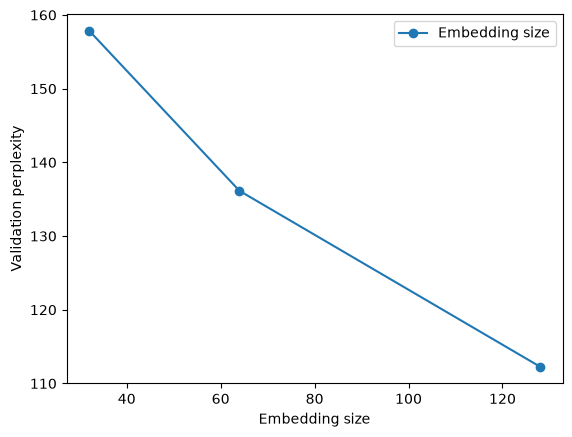

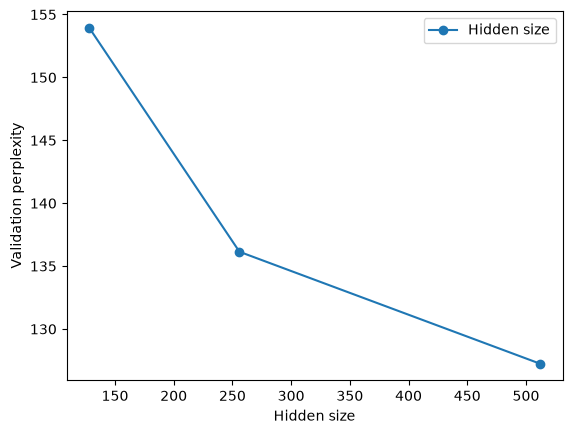

In [16]:
# plotting embedding size
embedding_results = experiment3_table[
    experiment3_table["Hyperparameter"] == "Embedding size"
]

plt.plot(
    embedding_results["Value"],
    embedding_results["Validation PP"],
    marker="o",
    label="Embedding size"
)

plt.xlabel("Embedding size")
plt.ylabel("Validation perplexity")
plt.legend()
plt.show()


# plotting hidden size
hidden_results = experiment3_table[
    experiment3_table["Hyperparameter"] == "Hidden size"
]

plt.plot(
    hidden_results["Value"],
    hidden_results["Validation PP"],
    marker="o",
    label="Hidden size"
)

plt.xlabel("Hidden size")
plt.ylabel("Validation perplexity")
plt.legend()
plt.show()

Increasing both embedding size and hidden size makes the validation perplexity lwoer. Embedding size has the stronger effect, because increasing it from 32 to 128 reduces perplexity more than increasing the hidden size from 128 to 512.

Task 5

1. Take your best model from Task 4. Generate ten samples with mode="sample" and three with
mode="argmax", using the generate function from Assignment 2 and the same three prompts.
Show them in the notebook.

In [17]:
# best model from Task 4 based on validation perplexity
best_model = model_embd
best_tokenizer = tok_1000

# now using Jeremy's real generate from Assignment 2 (evaluation.py),
# not a temporary stand-in anymore
from evaluation import generate

In [18]:
# same three prompts as in Assignment 2
prompts = [
    "shall i compare thee",
    "to be or not to",
    "o romeo, romeo,"
]


# generating 10 sampled texts
for i in range(10):

    prompt = prompts[i % 3]

    text = generate(
        best_model,
        best_tokenizer,
        strategy,
        prompt,
        mode="sample",
        max_tokens=50,
        seed=SEED + i
    )

    print(f"Sample {i + 1}:")
    print(text)
    print()


# generating 3 argmax texts
for i in range(3):

    prompt = prompts[i]

    text = generate(
        best_model,
        best_tokenizer,
        strategy,
        prompt,
        mode="argmax",
        max_tokens=50,
        seed=SEED
    )

    print(f"Argmax {i + 1}:")
    print(text)
    print()

Sample 1:
of the untie, toinllow ck surly .

Sample 2:
pardon aumerle:

Sample 3:
as in blood, what tigrown your deathsts of my boce his heard

Sample 4:
ll, cld toseduce:

Sample 5:
suppadlongs

Sample 6:
romeloned by the mays,

Sample 7:
can which was that murder,

Sample 8:
her hide marsha!

Sample 9:
wis,

Sample 10:
care, is his are she speak my soul gentleto make me been  sweet.

Argmax 1:
to the duke of york:

Argmax 2:
the duke of york:

Argmax 3:




Task 5.2

Preparing the Data

In [19]:
# Wall Street Journal test data (same file used again in Assignment 4)

import hashlib
import pathlib

wsj_url = "https://raw.githubusercontent.com/wojzaremba/lstm/master/data/ptb.test.txt"

pathlib.Path("data").mkdir(exist_ok=True)
wsj_path = pathlib.Path("data/ptb.test.txt")

if not wsj_path.exists():
    response = requests.get(wsj_url)
    response.encoding = "utf-8"
    wsj_path.write_text(response.text, encoding="utf-8")

# checking downloaded file
print("Number of lines:", len(wsj_path.read_text().splitlines()))
print("MD5:", hashlib.md5(wsj_path.read_bytes()).hexdigest())

# printing first two lines
wsj_lines_raw = wsj_path.read_text(encoding="utf-8").splitlines()

print(wsj_lines_raw[0])
print(wsj_lines_raw[1])

Number of lines: 3761
MD5: 8b80168b89c18661a38ef683c0dc3721
 no it was n't black monday 
 but while the new york stock exchange did n't fall apart friday as the dow jones industrial average plunged N points most of it in the final hour it barely managed to stay this side of chaos 


In [20]:
# replacing literal <unk> with unknown
wsj_lines = [
    line.replace("<unk>", "unknown")
    for line in wsj_lines_raw
]

# applying same normalization as before
wsj_lines = [
    normalize(line, strategy)
    for line in wsj_lines
]


# encoding WSJ with tokenizer of best neural model
bos_wsj = best_tokenizer.vocab["<bos>"]
eos_wsj = best_tokenizer.vocab["<eos>"]

wsj_sequences = [
    [bos_wsj] * (best_model.n - 1)
    + best_tokenizer.encode(line, count_unk=False)
    + [eos_wsj]
    for line in wsj_lines
]


# number of characters for perplexity per character
wsj_char_count = len("\n".join(wsj_lines))

Measure the count-based model from Assignment 2 and your best neural model on the Wall
Street Journal test file. Put the four numbers, both perplexity variants for both models, in one
table next to the Shakespeare numbers.

In [21]:
# evaluating count model on Shakespeare
count_shakespeare_pp, count_shakespeare_pp_char = perplexity(
    count_model,
    experiment1_models[1000]["test_sequences"],
    test_char_count
)

# evaluating best neural model on Shakespeare
best_neural_shakespeare_pp, best_neural_shakespeare_pp_char = perplexity(
    best_model,
    experiment1_models[1000]["test_sequences"],
    test_char_count
)


# evaluating count model on WSJ
count_wsj_pp, count_wsj_pp_char = perplexity(
    count_model,
    wsj_sequences,
    wsj_char_count
)

# evaluating best neural model on WSJ
best_neural_wsj_pp, best_neural_wsj_pp_char = perplexity(
    best_model,
    wsj_sequences,
    wsj_char_count
)


# comparing Shakespeare and WSJ
task5_results = [
    {
        "Model": "Count N-Gram",
        "Shakespeare PP": count_shakespeare_pp,
        "Shakespeare PP char": count_shakespeare_pp_char,
        "WSJ PP": count_wsj_pp,
        "WSJ PP char": count_wsj_pp_char
    },
    {
        "Model": "Neural N-Gram",
        "Shakespeare PP": best_neural_shakespeare_pp,
        "Shakespeare PP char": best_neural_shakespeare_pp_char,
        "WSJ PP": best_neural_wsj_pp,
        "WSJ PP char": best_neural_wsj_pp_char
    }
]

task5_table = pd.DataFrame(task5_results)

display(task5_table.round(3))

,Model,Shakespeare PP,Shakespeare PP char,WSJ PP,WSJ PP char
0,Count N-Gram,498.419,11.363,709.754,13.101
1,Neural N-Gram,142.116,6.955,277.555,9.068


Task 5.3

Say in two sentences why both models get worse, and which one gets worse faster

Both models perform worse on the Wall Street Journal data because they were trained on Shakespeare, which has a different vocabulary and writing style. The neural n-gram gets worse faster.